In [20]:
# Student Performance Prediction Using Machine Learning

## Libraries Import
## Load Dataset
## Dataset Information
## Data Preprocessing
## Feature Selection
## Train Test Split
## Linear Regression Model
## Decision Tree Model
## Model Evaluation
## Model Comparison
## Data Visualization
## Prediction
## Save Model
## Conclusion

In [4]:
# =====================================================
# LIBRARIES IMPORT
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib

In [5]:
# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("C:/Users/MOHIT_JAIN/Downloads/student_performance.csv")

print("First 5 Records")
print(df.head())

First 5 Records
   study_hours  attendance  previous_score  sleep_hours  \
0            1          77              52            8   
1            7          86              74            8   
2            6          86              49            5   
3            4          78              77            8   
4            4          94              76            5   

   assignments_completed  final_score  
0                      3           40  
1                      9           68  
2                      3           50  
3                      8           61  
4                      5           63  


In [6]:
# =====================================================
# DATASET INFORMATION
# =====================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(120, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   study_hours            120 non-null    int64
 1   attendance             120 non-null    int64
 2   previous_score         120 non-null    int64
 3   sleep_hours            120 non-null    int64
 4   assignments_completed  120 non-null    int64
 5   final_score            120 non-null    int64
dtypes: int64(6)
memory usage: 5.8 KB
None

Statistical Summary:
       study_hours  attendance  previous_score  sleep_hours  \
count   120.000000  120.000000      120.000000   120.000000   
mean      4.675000   79.533333       68.566667     6.441667   
std       2.227266   10.790545       14.514399     1.172484   
min       1.000000   60.000000       45.000000     5.000000   
25%       3.000000   71.000000       56.000000     5.000000   
50%    

In [7]:
# =====================================================
# CHECK MISSING VALUES
# =====================================================

print(df.isnull().sum())

study_hours              0
attendance               0
previous_score           0
sleep_hours              0
assignments_completed    0
final_score              0
dtype: int64


In [8]:
# =====================================================
# DEFINE FEATURES AND TARGET VARIABLE
# =====================================================

X = df[['study_hours',
        'attendance',
        'previous_score',
        'sleep_hours',
        'assignments_completed']]

y = df['final_score']

In [9]:
# =====================================================
# SPLIT DATA INTO TRAINING AND TESTING SET
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (96, 5)
Testing Shape: (24, 5)


In [10]:
# =====================================================
# LINEAR REGRESSION MODEL TRAINING
# =====================================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [11]:
# =====================================================
# LINEAR REGRESSION EVALUATION
# =====================================================

lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

print("Linear Regression Results")
print("R2 Score :", lr_r2)
print("MSE :", lr_mse)

Linear Regression Results
R2 Score : 0.8973212002344697
MSE : 9.243231120559509


In [12]:
# =====================================================
# DECISION TREE MODEL TRAINING
# =====================================================

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [13]:
# =====================================================
# DECISION TREE EVALUATION
# =====================================================

dt_r2 = r2_score(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)

print("Decision Tree Results")
print("R2 Score :", dt_r2)
print("MSE :", dt_mse)

Decision Tree Results
R2 Score : 0.769969256347435
MSE : 20.707559235890283


In [14]:
# =====================================================
# MODEL COMPARISON
# =====================================================

print("Linear Regression R2 Score :", lr_r2)
print("Decision Tree R2 Score :", dt_r2)

if lr_r2 > dt_r2:
    best_model = lr_model
    print("\nBest Model : Linear Regression")
else:
    best_model = dt_model
    print("\nBest Model : Decision Tree Regressor")

Linear Regression R2 Score : 0.8973212002344697
Decision Tree R2 Score : 0.769969256347435

Best Model : Linear Regression


In [15]:
# =====================================================
# ACTUAL VS PREDICTED VALUES
# =====================================================

comparison = pd.DataFrame({
    'Actual Score': y_test,
    'Predicted Score': best_model.predict(X_test)
})

print(comparison.head(10))

     Actual Score  Predicted Score
44             43        45.808989
47             55        58.776501
4              63        59.168260
55             47        46.845794
26             53        50.213840
64             57        58.868265
73             45        43.803977
10             50        55.395928
40             46        50.749265
107            65        65.240900


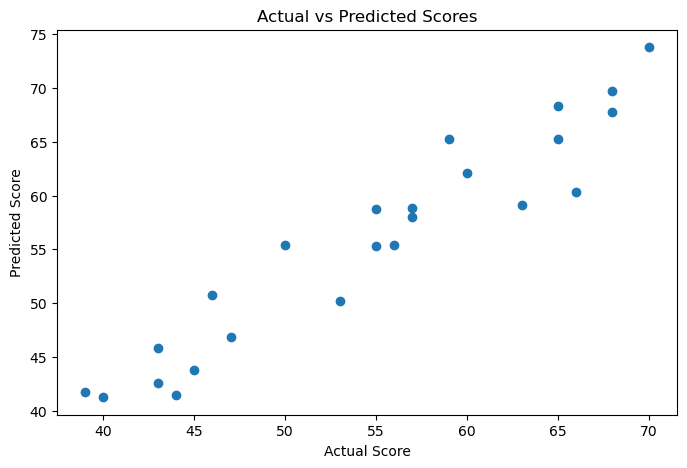

In [16]:
# =====================================================
# DATA VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    best_model.predict(X_test)
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.show()

In [17]:
# =====================================================
# PREDICT NEW STUDENT PERFORMANCE
# =====================================================

new_student = [[5, 90, 75, 7, 8]]

prediction = best_model.predict(new_student)

print("Predicted Final Score :", prediction[0])

Predicted Final Score : 64.2805673862194


C:\Users\MOHIT_JAIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
# =====================================================
# SAVE BEST MODEL
# =====================================================

joblib.dump(
    best_model,
    "student_performance_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
# =====================================================
# LOAD SAVED MODEL
# =====================================================

loaded_model = joblib.load(
    "student_performance_model.pkl"
)

prediction = loaded_model.predict(
    [[6, 92, 80, 8, 9]]
)

print("Prediction :", prediction[0])

Prediction : 70.3277000950799


C:\Users\MOHIT_JAIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
